# Chapter 22. 작은 BERT 직접 사전학습 — 한국어 MLM (scratch)

**목표**: Phase 3 의 네 번째 챕터. Ch 20 에서 *영어 작은 BERT* 를 random init 해 MLM 사전학습 했다면, 이번엔 *완전히 같은 본체 구조* 로 **한국어 MLM 사전학습** 합니다. 변하는 축은 **언어** — 토크나이저는 `klue/bert-base` (한국어 WordPiece, vocab 약 32,000), 데이터는 **한국어 Wikipedia** (`wikimedia/wikipedia`, `20231101.ko`) paragraphs. 본체 hyperparam, loss, training args 는 Ch 20 과 동일. *Ch 23 의 분류 fine-tune (NSMC 영화 리뷰) 은 완전히 다른 도메인* — 일반 도메인 사전학습 → task 도메인 fine-tune 의 정직한 transfer 메시지.

**환경**: Google Colab **T4 GPU 필수**.

**예상 소요 시간**: 약 5-8분 (토크나이저 로드 + ko 위키 다운로드·paragraph split·토큰화가 대부분을 차지 + MLM 2 epoch 약 0.3분 + 평가/저장). 전체 소요는 데이터 다운로드가 지배합니다.

---

## 학습 흐름

1. 🔤 **토크나이저**: `klue/bert-base` WordPiece (vocab 약 32,000) 그대로 로드
2. 📥 **데이터**: 한국어 Wikipedia (`wikimedia/wikipedia`, `20231101.ko`), paragraph 단위 5,000 sample (라벨 없음 — Wikipedia 본문)
3. 🚀 **토큰화 + `group_texts`**: Ch 20 과 같은 패턴 — 모든 텍스트를 이어붙여 `block_size=128` 블록 스트림
4. 🏗️ **모델 구성**: Ch 20 과 같은 `BertConfig(hidden_size=256, num_hidden_layers=4, num_attention_heads=4, intermediate_size=1024)` + `BertForMaskedLM(config)` random init
5. 🚀 **학습**: `DataCollatorForLanguageModeling(mlm=True, mlm_probability=0.15)` + Trainer, fp16, 2 epoch
6. 🔬 **평가**: MLM loss 학습 곡선, perplexity, 한국어 [MASK] 토큰 예측 시연
7. 💾 **저장**: `model.save_pretrained("./ch22_small_bert_mlm_ko")` — Ch 23 에서 분류 fine-tune

---

> 📒 **사전 학습 자료**: Ch 19 §5-4 (cross-language UNK) — *영어 토크나이저로 한국어를 처리하면 UNK·자모 폭증* 을 봤습니다. 이번 챕터는 그 결론을 *한국어 데이터엔 한국어 토크나이저 + 한국어 사전학습이 자연스럽다* 로 잇습니다. Ch 20 (영어 MLM scratch) 의 본체·셋업을 그대로 가져와 *언어 한 축만* 바꿉니다.

## 📊 변화추적표

| Ch | 모델 | 토크나이저 | 데이터 | Output Head | Activation | Loss |
|---|---|---|---|---|---|---|
| 19 | — (토크나이저 학습 전용) | WordPiece + WordLevel (둘 다 직접 학습) | Yelp text + NSMC text | — | — | — |
| 20 | 작은 BERT (직접, scratch) | `bert-base-uncased` 토크나이저 (가져옴) | Wikitext-103 paragraphs (일반 도메인) | MLM head | softmax (MLM) | `CrossEntropyLoss` (masked token) |
| 21 | Ch 20 사전학습 BERT + 분류 헤드 | (Ch 20과 동일) | Yelp 이진화 | `Linear(H, 2)` | softmax | `CrossEntropyLoss` |
| **22 ← 여기** | **작은 BERT (직접, scratch) — 한국어** | **`klue/bert-base` 토크나이저 (가져옴)** | **한국어 Wikipedia paragraphs** | **MLM head** | softmax (MLM) | **`CrossEntropyLoss` (masked token)** |
| 23 (다음) | Ch 22 사전학습 BERT + 분류 헤드 | (Ch 22와 동일) | NSMC 이진 | `Linear(H, 2)` | softmax | `CrossEntropyLoss` |

전체 챕터 표는 [루트 README.md](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표)를 참고하세요.

**Phase 3 안에서의 위치** — Ch 19 (토크나이저 학습) → Ch 20 (영어 모델 사전학습) → Ch 21 (영어 분류) → **Ch 22 (한국어 모델 사전학습)** → Ch 23 (한국어 분류). Ch 22 → Ch 23 흐름이 Ch 20 → Ch 21 흐름의 *한국어 대칭본*. 클라이맥스는 Ch 23 — *우리가 직접 사전학습한 작은 한국어 BERT* 와 *기존 `klue/bert-base` 사전학습 모델* (Ch 15) 의 정량 비교.

## 🔄 변경점 (Diff from Ch 20)

| 축 | Ch 20 (영어 MLM scratch) | Ch 22 (한국어 MLM scratch) |
|---|---|---|
| **언어** | 영어 | **한국어** ← *유일한 변화* |
| 토크나이저 | `bert-base-uncased` (vocab 30,522, 영어 WordPiece) | **`klue/bert-base` (vocab 약 32,000, 한국어 WordPiece)** |
| 데이터 | Wikitext-103 paragraphs 5K (일반 도메인, `Salesforce/wikitext`) | **한국어 Wikipedia paragraphs 5K (`wikimedia/wikipedia` 20231101.ko)** |
| 본체 hyperparam | `BertConfig(hidden=256, layer=4, head=4, intermediate=1024)` | (그대로) |
| 모델 클래스 | `BertForMaskedLM` (random init) | (그대로) |
| Collator | `DataCollatorForLanguageModeling(mlm_probability=0.15)` | (그대로) |
| Training args | epoch=2, batch=32, lr=5e-4, warmup=0.06, fp16 | (그대로) |
| Loss | `CrossEntropyLoss` (masked token, vocab 30,522 logits) | **`CrossEntropyLoss`** (masked token, vocab 약 32,000 logits) |
| 산출물 | `./ch20_small_bert_mlm` | **`./ch22_small_bert_mlm_ko`** — Ch 23 재사용 |

> **변경점 한 가지 원칙** — Phase 3 안에서 *언어 축* 만 변합니다. 본체 구조도 학습 셋업도 동일. *같은 코드를 한국어 토크나이저 + 한국어 데이터로 돌렸을 때 같은 결이 나오는가* 가 본 챕터의 검증 포인트.

### 왜 한국어엔 한국어 토크나이저인가 — Ch 19 §5-4 결론 잇기

Ch 19 의 cross-language 실험에서 *영어 토크나이저로 한국어를 토큰화하면 UNK 비율이 폭증* 한다는 걸 봤습니다. 그 위에서 모델을 사전학습하면 *언어 정보 자체가 사라진 [UNK] 자리* 가 대부분이라 학습 신호가 거의 없습니다.

이번 챕터는 그 결론의 자연스러운 다음 단계: **언어 데이터에 맞는 vocab 으로 토크나이저를 가져온 뒤 모델을 사전학습**. 토크나이저까지 *직접 학습* 하지 않은 이유는 Ch 20 과 같습니다 — `klue/bert-base` 의 vocab 은 한국어 위키 + 뉴스 + 댓글 등 대규모 코퍼스로 학습되어 *어휘 커버리지가 검증된* 출발점.

## 📐 Loss 함수의 변화 — *없음*. Ch 20 과 같은 MLM CE

이번 챕터는 *언어만 바뀌고* loss 함수는 Ch 20 과 동일한 MLM CrossEntropyLoss. 가려진 위치의 *원래 토큰* 을 vocab 차원 softmax 로 예측. 다만 vocab 크기가 살짝 달라 random baseline 이 미세하게 이동합니다.

### 수식 (Ch 20 과 동일)

$$L_{\text{MLM}} = -\frac{1}{|M|} \sum_{i \in M} \log P(x_i \mid x_{\setminus M})$$

- $M$: 가려진 위치 집합 (전체 토큰의 약 15%)
- $P(x_i \mid x_{\setminus M})$: 모델이 $i$ 번 위치에 *원래 토큰* 을 예측할 확률 (vocab 약 32,000 차원 softmax)

### vocab 차이가 random baseline 에 주는 미세한 영향

| 토크나이저 | vocab size $V$ | random baseline $\log V$ | random PPL $= V$ |
|---|---|---|---|
| `bert-base-uncased` (Ch 20) | 30,522 | **10.33** | 30,522 |
| `klue/bert-base` (Ch 22) | 32,000 | **10.37** | 32,000 |

차이는 약 0.04 정도로 *거의 무시할 수준*. 학습 첫 step 의 loss 가 약 10.37 부근이면 random init 직후 *균등 추측* 상태. 첫 100 step 안에 빠르게 떨어지면 vocab 정상 작동.

> 분류 챕터에서 K (클래스 수) 가 늘 때 random baseline `log K` 가 커지듯, MLM 도 vocab 이 커지면 random baseline 이 커집니다. 하지만 vocab 30K vs 32K 정도의 차이는 *학습 동역학에 영향 없음* — 학습 종료 loss 의 절대값을 비교할 때만 미세 보정.

### 학습 목표 영역 (Ch 20 과 같음)

| 모델 상태 | $-\log p$ | 해석 |
|---|---|---|
| 균등 추측 (random init 직후) | 10.37 | random baseline |
| 약하게 학습 (정답 확률 0.01) | 4.61 | |
| 잘 학습된 작은 BERT (정답 확률 0.05-0.1) | 2.3 - 3.0 | 이번 챕터 목표 영역 |
| 큰 사전학습 BERT (정답 확률 0.3+) | 1.20 | `klue/bert-base` 본체 수준 |

**관전 포인트** — Ch 20 의 영어 MLM 과 *비슷한 수렴 곡선* 이 나오는지가 본 챕터의 핵심 관찰. *언어가 달라도 작은 BERT + 5K 문장 MLM 의 학습 동역학은 비슷하다* 가 검증 가설.

## 🔤 토크나이저 노트 — 본 챕터의 핵심 한 자리

Ch 19 §5-4 의 cross-language 결론을 *실측* 으로 다시 확인합니다. 같은 한국어 문장을 *영어 토크나이저 (`bert-base-uncased`)* 와 *한국어 토크나이저 (`klue/bert-base`)* 에 통과시켜 토큰 리스트·UNK 개수를 비교 — 왜 한국어 데이터엔 한국어 토크나이저가 필요한가 의 직접 답.

> 이 비교 표는 *코드 셀 2 - 토크나이저 로드* 에서 직접 실행합니다. 여기서는 결론만 한 줄: **한국어 토크나이저는 한국어를 어절·형태소 단위로 자연스럽게 쪼개고 UNK 가 거의 없음. 영어 토크나이저는 한국어를 *자모 단위* 또는 *UNK 폭증* 으로 잘못 쪼갬.**

### 한국어 BERT 의 표준 토크나이저 — `klue/bert-base`

- `AutoTokenizer.from_pretrained("klue/bert-base")`
- vocab_size = 약 32,000 (한국어 WordPiece)
- 학습 코퍼스 = 한국어 위키 + 모두의 말뭉치 + 뉴스 + 댓글 → 한국어 일반 분포 + 비격식 텍스트 모두 커버
- 특수 토큰: `[PAD]=0`, `[UNK]=1`, `[CLS]=2`, `[SEP]=3`, `[MASK]=4`

> Ch 21 에서 `bert-base-uncased` 토크나이저를 *사전학습-fine-tune 전 구간* 에서 동일하게 썼듯, 이번 챕터의 `klue/bert-base` 토크나이저는 Ch 23 분류 fine-tune 까지 *그대로* 이어집니다. 토크나이저와 모델 본체는 *함께 가야 의미가 유지* 됩니다.

### `labels = -100` 한 줄 환기

`DataCollatorForLanguageModeling` 이 가려지지 않은 자리에 `labels = -100` 을 채워 *해당 위치의 CE loss 를 무시* 합니다 (PyTorch `CrossEntropyLoss` 의 `ignore_index` 기본값). 같은 트릭이 Phase 4 의 SFT (Ch 28) 에서 *prompt 자리를 가리는* 방식으로 다시 등장합니다 — *적용 자리만 정반대*. 한국어 MLM 에서도 트릭 자체는 *완전히 동일*.

## 🛠️ 환경 셋업

In [1]:
%pip install -q -U transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/50.1 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.1/50.1 MB 212.1 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.1/50.1 MB 212.1 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.1/50.1 MB 212.1 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 92.9 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    BertConfig,
    BertForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    set_seed,
    TrainingArguments,
)

plt.rcParams["axes.unicode_minus"] = False

# matplotlib 한글 폰트 (Colab — NanumGothic). plot 의 한국어가 □ 로 깨지지 않게.
import matplotlib.font_manager as fm, subprocess, os
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not os.path.exists(_fp):
    subprocess.run("apt-get -qq -y install fonts-nanum", shell=True)
fm.fontManager.addfont(_fp)
plt.rcParams["font.family"] = "NanumGothic"

# device 자동감지 — Colab(T4) 은 CUDA, 로컬 Mac 은 MPS, 그 외 CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device:         {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
elif DEVICE == "cpu":
    print("Warning: CPU runtime — MLM training will be very slow. Switch to T4 recommended.")

PyTorch:        2.11.0+cu128
CUDA available: True
Device:         cuda
GPU:             Tesla T4


**baseline VRAM** (CUDA 환경에서만 의미 있는 출력 — Colab T4 기준):

In [3]:
!nvidia-smi

Fri Aug 28 08:54:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. 📥 한국어 Wikipedia 데이터 로드 — 일반 도메인 사전학습 코퍼스

원본 BERT 가 영어 Wikipedia + BookCorpus 라는 *일반 도메인* 코퍼스로 사전학습한 정신을 따라, 본 챕터도 **한국어 Wikipedia 본문** 으로 MLM 사전학습합니다 — *task 도메인 (NSMC 영화 리뷰) 으로 사전학습하면 domain-adaptive pretraining 에 가까워져 사전학습의 진짜 메시지 (일반 표상 학습 → 다른 task 로 transfer) 가 흐려지기 때문*.

**원본**: `wikimedia/wikipedia`, config `20231101.ko`. CC-BY-SA, HF Hub 정제본. article 단위 다운로드 후 paragraph 단위로 split 해 NSMC 5K 문장과 비슷한 토큰 양으로 맞춤. Ch 23 의 분류 fine-tune (NSMC 이진) 은 *완전히 다른 도메인* — 사전학습 → fine-tune transfer 메시지가 정직해집니다.

In [4]:
from datasets import load_dataset

print("downloading Korean Wikipedia (wikimedia/wikipedia, 20231101.ko)...")
ds_raw = load_dataset("wikimedia/wikipedia", "20231101.ko", split="train")
print(f"  total articles: {len(ds_raw):,}")
print()
print(f"first 3 article previews:")
for i in range(3):
    title = ds_raw[i]["title"]
    text  = ds_raw[i]["text"]
    print(f"  Article {i} ({title}): {text[:80].strip()}")

downloading Korean Wikipedia (wikimedia/wikipedia, 20231101.ko)...


README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

20231101.ko/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  400MB            

20231101.ko/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

20231101.ko/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  205MB            

20231101.ko/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

20231101.ko/train-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  177MB            

20231101.ko/train-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/647897 [00:00<?, ? examples/s]

  total articles: 647,897

first 3 article previews:
  Article 0 (지미 카터): 제임스 얼 카터 주니어(, 1924년 10월 1일~)는 민주당 출신 미국의 제39대 대통령(1977년~1981년)이다.

생애

어린 시절 
지
  Article 1 (수학): 수학(數學, , 줄여서 math)은 수, 양, 구조, 공간, 변화 등의 개념을 다루는 학문이다. 널리 받아들여지는 명확한 정의는 없으나 현대 수
  Article 2 (수학 상수): 수학에서 상수란 그 값이 변하지 않는 불변량으로, 변수의 반대말이다. 물리 상수와는 달리, 수학 상수는 물리적 측정과는 상관없이 정의된다.

수


In [5]:
SEED = 42
N_TRAIN_TEXT = 5000
N_EVAL_TEXT  = 500

# article 본문을 paragraph 단위로 잘라 N_TRAIN + N_EVAL 채우기.
# 너무 짧은 (제목·메타) 또는 너무 긴 (목록·인용) paragraph 제외.
def collect_paragraphs(ds, target, min_len=50, max_len=2000):
    out = []
    for ex in ds:
        for para in ex["text"].split("\n\n"):
            para = para.strip()
            if min_len <= len(para) <= max_len:
                out.append(para)
                if len(out) >= target:
                    return out
    return out

shuffled = ds_raw.shuffle(seed=SEED)
TARGET = N_TRAIN_TEXT + N_EVAL_TEXT
all_paragraphs = collect_paragraphs(shuffled, target=TARGET)

train_ds_raw = Dataset.from_dict({"text": all_paragraphs[:N_TRAIN_TEXT]})
eval_ds_raw  = Dataset.from_dict({"text": all_paragraphs[N_TRAIN_TEXT:N_TRAIN_TEXT + N_EVAL_TEXT]})

print(f"sampled train: {len(train_ds_raw):,} paragraphs")
print(f"sampled eval:  {len(eval_ds_raw):,} paragraphs")
print()
print(f"sample text length stats (chars):")
lens = [len(t) for t in train_ds_raw["text"]]
print(f"  mean: {np.mean(lens):.1f}, median: {np.median(lens):.0f}, max: {max(lens)}")
print()
print(f"first sample preview:")
for i in range(3):
    t = train_ds_raw[i]["text"]
    print(f"  Sample {i}: {t[:120]}")

sampled train: 5,000 paragraphs
sampled eval:  500 paragraphs

sample text length stats (chars):
  mean: 194.6, median: 143, max: 1979

first sample preview:
  Sample 0: 원(元)은 시호에 쓰이는 글자다. 《일주서》 시법해에는 능사변중(能思辨衆), 행의열민(行義說民), 시건국도(始建國都), 주의덕행(主義行德)을 일컫는다 한다.
  Sample 1: 원황제 
 전한 원제
 조위 원제
 동진 원제
 후조 원제 (추존)
 북연 원제 (추존)
 염위 원제 (추존)
 하 원제 (추존)
 대 원제 (추존)
 양 원제
 한 원제 (추존)
 당 원제
 북송 원제
 금 원제
  Sample 2: 애그리게이션(aggregation)은 다음을 가리킨다.
 링크 애그리게이션(link aggregation)
 패킷 애그리게이션(packet aggregation)
 뉴스 애그리게이션(news aggregation)



## 2. 🔤 토크나이저 — `klue/bert-base` 로드 + 영어 토크나이저와 한국어 비교

`klue/bert-base` 의 한국어 WordPiece (vocab 약 32,000) 를 그대로 가져옵니다. *모델은 random init* 이지만 토크나이저는 *완성품* — Ch 20 의 영어 패턴과 동일.

이어서 같은 한국어 문장을 *영어 토크나이저* (`bert-base-uncased`, Ch 20 에서 사용) 와 비교해 Ch 19 §5-4 의 cross-language 결론을 *직접* 확인합니다.

In [6]:
TOKENIZER_NAME = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

print(f"tokenizer:        {TOKENIZER_NAME}")
print(f"vocab_size:       {tokenizer.vocab_size:,}")
print(f"model_max_length: {tokenizer.model_max_length}")
print(f"special tokens:")
for name in ("pad_token", "unk_token", "cls_token", "sep_token", "mask_token"):
    tok = getattr(tokenizer, name)
    tid = tokenizer.convert_tokens_to_ids(tok) if tok is not None else None
    print(f"  {name:>11}: {tok!r:>10}  (id={tid})")

# 간단 시연 — 한국어 문장
SAMPLE_KO = "이 영화 정말 재미있어요!"
enc = tokenizer(SAMPLE_KO, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
print(f"\nKorean sample: {SAMPLE_KO!r}")
print(f"tokens ({len(tokens)}): {tokens}")
print(f"ids:    {enc['input_ids'][0].tolist()}")

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

tokenizer:        klue/bert-base
vocab_size:       32,000
model_max_length: 512
special tokens:
    pad_token:    '[PAD]'  (id=0)
    unk_token:    '[UNK]'  (id=1)
    cls_token:    '[CLS]'  (id=2)
    sep_token:    '[SEP]'  (id=3)
   mask_token:   '[MASK]'  (id=4)

Korean sample: '이 영화 정말 재미있어요!'
tokens (8): ['[CLS]', '이', '영화', '정말', '재미있', '##어요', '!', '[SEP]']
ids:    [2, 1504, 3771, 3944, 6001, 10283, 5, 3]


### 🌐 같은 한국어 문장을 두 토크나이저로 — Ch 19 §5-4 cross-language 검증

영어 토크나이저 (`bert-base-uncased`) 와 한국어 토크나이저 (`klue/bert-base`) 에 같은 한국어 문장을 통과시켜 토큰 리스트와 UNK 개수를 비교합니다.

In [7]:
# 영어 토크나이저 (Ch 20 에서 사용한 것) 도 로드해 비교
tokenizer_en = AutoTokenizer.from_pretrained("bert-base-uncased")

EN_NAME = "bert-base-uncased (EN)"
KO_NAME = "klue/bert-base (KO)"

ko_sentences = [
    "이 영화 정말 재미있어요!",
    "음식이 맛있었고 서비스도 훌륭했습니다.",
    "별로였어요. 시간 낭비.",
]

cross_rows = []
for sent in ko_sentences:
    for name, tok in [(EN_NAME, tokenizer_en), (KO_NAME, tokenizer)]:
        enc = tok(sent, add_special_tokens=False)
        toks = tok.convert_ids_to_tokens(enc["input_ids"])
        n_unk = sum(1 for t in toks if t == "[UNK]")
        cross_rows.append({
            "sentence": sent,
            "tokenizer": name,
            "n_tokens": len(toks),
            "n_unk": n_unk,
            "unk_pct": round(n_unk / len(toks) * 100, 1) if toks else 0.0,
        })

cross_df = pd.DataFrame(cross_rows)
print(cross_df.to_string(index=False))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

             sentence              tokenizer  n_tokens  n_unk  unk_pct
       이 영화 정말 재미있어요! bert-base-uncased (EN)        15      1      6.7
       이 영화 정말 재미있어요!    klue/bert-base (KO)         6      0      0.0
음식이 맛있었고 서비스도 훌륭했습니다. bert-base-uncased (EN)        19      2     10.5
음식이 맛있었고 서비스도 훌륭했습니다.    klue/bert-base (KO)        12      0      0.0
        별로였어요. 시간 낭비. bert-base-uncased (EN)        13      1      7.7
        별로였어요. 시간 낭비.    klue/bert-base (KO)         7      0      0.0


In [8]:
# 실제 토큰 리스트도 한 번 보여줍니다 (첫 12 토큰)
print("=" * 78)
for sent in ko_sentences:
    print(f"\n[Korean input] {sent}")
    for name, tok in [(EN_NAME, tokenizer_en), (KO_NAME, tokenizer)]:
        enc = tok(sent, add_special_tokens=False)
        toks = tok.convert_ids_to_tokens(enc["input_ids"])
        head = toks[:12]
        n_unk = sum(1 for t in toks if t == "[UNK]")
        print(f"  {name:28} ({len(toks):>3} tokens, UNK {n_unk:>2}): {head}")


[Korean input] 이 영화 정말 재미있어요!
  bert-base-uncased (EN)       ( 15 tokens, UNK  1): ['ᄋ', '##ᅵ', 'ᄋ', '##ᅧ', '##ᆼ', '##ᄒ', '##ᅪ', 'ᄌ', '##ᅥ', '##ᆼ', '##ᄆ', '##ᅡ']
  klue/bert-base (KO)          (  6 tokens, UNK  0): ['이', '영화', '정말', '재미있', '##어요', '!']

[Korean input] 음식이 맛있었고 서비스도 훌륭했습니다.
  bert-base-uncased (EN)       ( 19 tokens, UNK  2): ['ᄋ', '##ᅳ', '##ᆷ', '##ᄉ', '##ᅵ', '##ᆨ', '##ᄋ', '##ᅵ', '[UNK]', 'ᄉ', '##ᅥ', '##ᄇ']
  klue/bert-base (KO)          ( 12 tokens, UNK  0): ['음식', '##이', '맛있', '##었', '##고', '서비스', '##도', '훌륭', '##했', '##습', '##니다', '.']

[Korean input] 별로였어요. 시간 낭비.
  bert-base-uncased (EN)       ( 13 tokens, UNK  1): ['[UNK]', '.', 'ᄉ', '##ᅵ', '##ᄀ', '##ᅡ', '##ᆫ', 'ᄂ', '##ᅡ', '##ᆼ', '##ᄇ', '##ᅵ']
  klue/bert-base (KO)          (  7 tokens, UNK  0): ['별로', '##였', '##어요', '.', '시간', '낭비', '.']


**관찰 — Ch 19 §5-4 결론의 실측 확인**

- **`bert-base-uncased` (영어)**: 한국어 문장이 *자모 단위* (`ᄋ`, `##ᅵ`, `##ᅧ` ...) 로 분해되거나 `[UNK]` 가 섞임. 토큰 수가 길게 폭증, *의미 단위* 가 사라짐. 모델이 이 표현으로 학습해도 *한국어 어휘 정보* 가 거의 없음.
- **`klue/bert-base` (한국어)**: 한국어 문장이 *어절·형태소* 단위 (`이`, `영화`, `정말`, `재미있`, `##어요`) 로 자연스럽게 쪼개짐. UNK 0개, 토큰 수가 짧고 *의미 단위* 가 보존.

> **결론** — 한국어 데이터로 BERT 를 사전학습하려면 한국어 토크나이저가 필수. Ch 20 의 영어 패턴을 한국어로 옮길 때 *토크나이저만 바꿔도* 같은 학습 동역학이 가능합니다. Ch 19 §5-4 가 *문제 제기* 였다면, 이번 챕터는 *해결책의 첫 단계*.

## 3. 🚀 토큰화 + `group_texts` — Ch 20 패턴 그대로

MLM 사전학습 표준 입력 포맷. 모든 문서를 *이어 붙여 토큰 스트림* 으로 만든 뒤 `block_size=128` 단위로 자릅니다. 문장 경계가 사라지는 trade-off 는 있지만 BERT 사전학습은 *임의 위치의 토큰 예측* 이라 문장 경계가 중요하지 않습니다.

한국어 Wikipedia paragraphs 는 *제한 50-2000자 필터링* 으로 평균 문장 길이가 일정 (수십 자-수백 자). 5,000 paragraphs 이 `block_size=128` 로 잘리면 약 500-1,500 블록 정도로 정리됩니다. NSMC 한 줄 리뷰보다 길고 Yelp 보다는 짧은 중간 수준 — 일반 도메인 코퍼스다운 균형.

In [9]:
BLOCK_SIZE = 128

def tokenize_function(examples):
    # 특수 토큰 부착 안 함 — 블록 단위로 자를 거라 [CLS]/[SEP] 가 의미 없음
    return tokenizer(examples["text"], add_special_tokens=False, truncation=False)

tokenized_train = train_ds_raw.map(
    tokenize_function, batched=True, remove_columns=["text"],
)
tokenized_eval = eval_ds_raw.map(
    tokenize_function, batched=True, remove_columns=["text"],
)
print(f"tokenized_train: {tokenized_train}")
print(f"first 30 input_ids of sample 0: {tokenized_train[0]['input_ids'][:30]}")
print(f"first 30 tokens of sample 0:    {tokenizer.convert_ids_to_tokens(tokenized_train[0]['input_ids'][:30])}")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (610 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

tokenized_train: Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})
first 30 input_ids of sample 0: [1478, 12, 244, 13, 1497, 24307, 2170, 8026, 2259, 8034, 2062, 18, 170, 16164, 2112, 171, 1325, 2520, 2097, 2170, 2259, 797, 2063, 2447, 2284, 12, 471, 353, 1, 1]
first 30 tokens of sample 0:    ['원', '(', '元', ')', '은', '시호', '##에', '쓰이', '##는', '글자', '##다', '.', '《', '일주', '##서', '》', '시', '##법', '##해', '##에', '##는', '능', '##사', '##변', '##중', '(', '能', '思', '[UNK]', '[UNK]']


In [10]:
def group_texts(examples):
    '''HF 표준 group_texts — 모든 토큰 스트림을 이어 붙인 뒤 block_size 로 자름.'''
    concatenated = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated[list(examples.keys())[0]])
    # block_size 배수로 잘라내기 (마지막 토막은 버림)
    total_length = (total_length // BLOCK_SIZE) * BLOCK_SIZE
    result = {
        k: [t[i : i + BLOCK_SIZE] for i in range(0, total_length, BLOCK_SIZE)]
        for k, t in concatenated.items()
    }
    # labels = input_ids 사본 (collator 가 mask 위치만 골라냄)
    result["labels"] = [ids.copy() for ids in result["input_ids"]]
    return result


lm_train = tokenized_train.map(group_texts, batched=True, batch_size=1000)
lm_eval  = tokenized_eval.map(group_texts,  batched=True, batch_size=1000)

print(f"lm_train: {lm_train}")
print(f"lm_eval:  {lm_eval}")
print(f"\nblock_size:           {BLOCK_SIZE}")
print(f"train blocks: {len(lm_train):,}  (approx. {len(lm_train) * BLOCK_SIZE:,} tokens)")
print(f"eval blocks:  {len(lm_eval):,}   (approx. {len(lm_eval) * BLOCK_SIZE:,} tokens)")
print(f"\nsample block 0 first 20 ids: {lm_train[0]['input_ids'][:20]}")
print(f"sample block 0 first 20 tok: {tokenizer.convert_ids_to_tokens(lm_train[0]['input_ids'][:20])}")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

lm_train: Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 3924
})
lm_eval:  Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 429
})

block_size:           128
train blocks: 3,924  (approx. 502,272 tokens)
eval blocks:  429   (approx. 54,912 tokens)

sample block 0 first 20 ids: [1478, 12, 244, 13, 1497, 24307, 2170, 8026, 2259, 8034, 2062, 18, 170, 16164, 2112, 171, 1325, 2520, 2097, 2170]
sample block 0 first 20 tok: ['원', '(', '元', ')', '은', '시호', '##에', '쓰이', '##는', '글자', '##다', '.', '《', '일주', '##서', '》', '시', '##법', '##해', '##에']


## 4. 🏗️ 작은 `BertConfig` + `BertForMaskedLM` — random init (Ch 20 과 동일)

본체 구조는 Ch 20 과 *완전히 동일* — hidden=256, layer=4, head=4, intermediate=1024. vocab 만 한국어 토크나이저 (32,000) 에 맞춤.

In [11]:
HIDDEN_SIZE         = 256
NUM_HIDDEN_LAYERS   = 4
NUM_ATTENTION_HEADS = 4
INTERMEDIATE_SIZE   = 1024
MAX_POS_EMBED       = 128  # = BLOCK_SIZE

config = BertConfig(
    vocab_size=tokenizer.vocab_size,
    hidden_size=HIDDEN_SIZE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    num_attention_heads=NUM_ATTENTION_HEADS,
    intermediate_size=INTERMEDIATE_SIZE,
    max_position_embeddings=MAX_POS_EMBED,
    pad_token_id=tokenizer.pad_token_id,
)

# 모델 가중치에도 시드를 겁니다 — TrainingArguments(seed=) 는 Trainer 단계부터 적용되므로
# 이 줄이 없으면 random init 이 매 실행 달라져 loss·perplexity 가 실행마다 흔들립니다.
set_seed(SEED)

model = BertForMaskedLM(config)  # random init — pretrained weight 없음!

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
emb = sum(p.numel() for n, p in model.named_parameters() if "embeddings" in n)
encoder = sum(p.numel() for n, p in model.named_parameters() if "encoder" in n)
head = sum(p.numel() for n, p in model.named_parameters() if "cls" in n)

print(f"Config: hidden={HIDDEN_SIZE}, layer={NUM_HIDDEN_LAYERS}, "
      f"head={NUM_ATTENTION_HEADS}, intermediate={INTERMEDIATE_SIZE}")
print(f"max_position_embeddings: {MAX_POS_EMBED}")
print(f"vocab_size:              {tokenizer.vocab_size:,}  (klue/bert-base)")
print()
print(f"Total parameters:    {total:>13,}  ({total/1e6:.2f} M)")
print(f"Trainable:           {trainable:>13,}")
print(f"  embeddings:        {emb:>13,}  ({emb/total:.1%})  (vocab {tokenizer.vocab_size} x hidden {HIDDEN_SIZE})")
print(f"  encoder (4 layer): {encoder:>13,}  ({encoder/total:.1%})")
print(f"  MLM head:          {head:>13,}  ({head/total:.1%})  (tied with embeddings)")

Config: hidden=256, layer=4, head=4, intermediate=1024
max_position_embeddings: 128
vocab_size:              32,000  (klue/bert-base)

Total parameters:       11,483,136  (11.48 M)
Trainable:              11,483,136
  embeddings:            8,225,792  (71.6%)  (vocab 32000 x hidden 256)
  encoder (4 layer):     3,159,040  (27.5%)
  MLM head:                 98,304  (0.9%)  (tied with embeddings)


**관찰** — vocab 이 약 32,000 (Ch 20 의 30,522 보다 약간 큼) 이라 임베딩 테이블이 살짝 더 큽니다. 그래도 본체 구조는 동일 — encoder body 2M + 임베딩 8M 수준의 작은 BERT.

> Ch 20 과 마찬가지로 MLM head 의 weight 는 입력 임베딩과 *tied* (공유). vocab 차원 출력 layer 가 임베딩 테이블과 같아 파라미터 절약.

## 5. 🚀 `DataCollatorForLanguageModeling` + Trainer 학습

collator 가 매 batch 마다 *무작위로 약 15% 토큰을 [MASK]* 로 바꾸고, 그 위치의 정답 토큰을 `labels` 로 표시. 나머지 위치는 `-100` → CrossEntropyLoss 가 무시.

**MLM masking 규칙** (BERT 원논문) — Ch 20 / Ch 21 과 동일:
- 선택된 약 15% 중 80%: 실제로 `[MASK]` 로 교체
- 10%: 무작위 다른 토큰으로 교체
- 10%: 원래 토큰 유지

이 규칙은 *언어와 무관* — collator 코드가 토큰 id 만 보고 처리합니다.

In [12]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15,
)

# collator 동작 확인 — 같은 입력을 두 번 처리해 mask 위치가 매번 다른지 보기
sample_batch = [lm_train[0], lm_train[1]]
out1 = data_collator(sample_batch)
out2 = data_collator(sample_batch)

print(f"batch shape: input_ids={tuple(out1['input_ids'].shape)}, labels={tuple(out1['labels'].shape)}")
mask_id = tokenizer.mask_token_id

n_masked_1 = (out1["input_ids"] == mask_id).sum().item()
n_masked_2 = (out2["input_ids"] == mask_id).sum().item()
total_tokens = out1["input_ids"].numel()
print(f"masked tokens (call 1): {n_masked_1:>4} / {total_tokens}  ({n_masked_1/total_tokens:.2%})")
print(f"masked tokens (call 2): {n_masked_2:>4} / {total_tokens}  ({n_masked_2/total_tokens:.2%})")

# labels 에서 -100 이 아닌 위치 = MLM loss 가 계산되는 위치
n_loss_pos = (out1["labels"] != -100).sum().item()
print(f"loss positions:        {n_loss_pos:>4} / {total_tokens}  "
      f"({n_loss_pos/total_tokens:.2%})  (labels != -100)")

batch shape: input_ids=(2, 128), labels=(2, 128)
masked tokens (call 1):   30 / 256  (11.72%)
masked tokens (call 2):   27 / 256  (10.55%)
loss positions:          35 / 256  (13.67%)  (labels != -100)


### 5-1. 🔍 [MASK] 가 들어가는 원리 — 한 눈에 보는 80/10/10 (한국어 풀버전)

`DataCollatorForLanguageModeling` 은 매 step 마다 *입력 토큰의 약 15%* 를 *무작위로* 선택하고, 선택된 위치마다 세 가지 중 하나를 적용합니다.

| 선택된 토큰 운명 | 비율 | 의도 |
| --- | --- | --- |
| `[MASK]` 로 교체 | **80%** | 표준 마스킹 — 모델이 *주변 문맥만으로* 원래 토큰을 맞추도록 |
| **다른 random 토큰** 으로 교체 | 10% | inference 때는 `[MASK]` 가 없으니, 모델이 *항상* 자기 입력을 *의심* 하게 만듦 |
| **원본 그대로** 유지 | 10% | 동일 — 입력과 정답이 일치하는 케이스도 학습 데이터에 포함 |

**나머지 85%** 의 토큰은 `labels = -100` 으로 두어 *loss 계산에서 제외* 됩니다 (PyTorch CE 의 `ignore_index` 기본값). 즉 한 step 의 MLM loss 는 *선택된 15% 자리만* 모아 평균한 값.

> 이 `labels = -100` 트릭은 BERT-만의 것이 아닙니다 — Phase 4 GPT 사전학습은 *거의 모든 토큰* 을 학습 (`labels = input_ids`), SFT (Ch 28) 는 *prompt 만 -100, 답변만 학습*. 같은 트릭, 정반대 자리. Ch 21 / 영어 짝과 동일한 풀버전 시각화로 한국어 환경에서도 직접 확인.

In [13]:
# 한국어 예시 문장 한 개에 collator 한 번 적용 — 어떤 자리가 어떻게 바뀌나
DEMO_SENT_KO = "이 영화는 정말 재미있었고 배우들 연기도 훌륭했습니다."
demo_enc = tokenizer(DEMO_SENT_KO, return_tensors=None)
demo_ids = demo_enc["input_ids"]

torch.manual_seed(0)  # 재현성: 같은 seed 면 같은 마스킹
demo_batch = [{"input_ids": demo_ids, "attention_mask": [1] * len(demo_ids)}]
demo_out = data_collator(demo_batch)

masked_ids = demo_out["input_ids"][0].tolist()
labels     = demo_out["labels"][0].tolist()   # -100 = loss 무시, 그 외 = 원본 token id
mask_id_local = tokenizer.mask_token_id

orig_tokens   = tokenizer.convert_ids_to_tokens(demo_ids)
masked_tokens = tokenizer.convert_ids_to_tokens(masked_ids)

rows = []
for orig_id, new_id, lab, orig_tok, new_tok in zip(demo_ids, masked_ids, labels, orig_tokens, masked_tokens):
    if lab == -100:
        kind = "-"                       # 미선택 (loss 계산 X)
    elif new_id == mask_id_local:
        kind = "[MASK] (80%)"             # 표준 마스킹
    elif new_id == orig_id:
        kind = "kept (10%)"               # 선택됐지만 원본 유지
    else:
        kind = "random (10%)"             # 다른 token 으로 교체
    rows.append({
        "pos": len(rows),
        "original": orig_tok,
        "after_collator": new_tok,
        "label_id": lab,
        "what_happened": kind,
    })

demo_df = pd.DataFrame(rows)
print(demo_df.to_string(index=False))

 pos original after_collator  label_id what_happened
   0    [CLS]          [CLS]      -100             -
   1        이              이      -100             -
   2       영화         [MASK]      3771  [MASK] (80%)
   3      ##는            ##는      2259    kept (10%)
   4       정말             정말      -100             -
   5      재미있            재미있      -100             -
   6      ##었            ##었      -100             -
   7      ##고            ##고      -100             -
   8       배우             배우      -100             -
   9      ##들            ##들      -100             -
  10       연기             연기      -100             -
  11      ##도            ##도      -100             -
  12       훌륭         [MASK]      5825  [MASK] (80%)
  13      ##했            ##했      -100             -
  14      ##습            ##습      -100             -
  15     ##니다           ##니다      -100             -
  16        .              .      -100             -
  17    [SEP]          [SEP]      -100        

In [14]:
# 큰 batch 통계 — 80/10/10 비율이 실제로 맞는지 확인 (한국어 lm_train 사용)
torch.manual_seed(0)
N_DEMO = 64
big_batch = [
    {"input_ids": lm_train[i]["input_ids"], "attention_mask": [1] * BLOCK_SIZE}
    for i in range(N_DEMO)
]
big_out = data_collator(big_batch)

in_ids = big_out["input_ids"]
lab_big = big_out["labels"]

selected = (lab_big != -100)
n_total    = lab_big.numel()
n_selected = selected.sum().item()
n_mask     = ((in_ids == mask_id_local) & selected).sum().item()
n_kept     = ((in_ids == lab_big) & selected).sum().item()
n_random   = n_selected - n_mask - n_kept

print(f"Total tokens:                      {n_total:>7,}")
print(f"Selected for loss (target 15%):    {n_selected:>7,}  ({100 * n_selected / n_total:5.2f}%)")
print(f"  └─ replaced with [MASK]:         {n_mask:>7,}  ({100 * n_mask / n_selected:5.2f}% of selected)")
print(f"  └─ replaced with random:         {n_random:>7,}  ({100 * n_random / n_selected:5.2f}% of selected)")
print(f"  └─ kept as original:             {n_kept:>7,}  ({100 * n_kept / n_selected:5.2f}% of selected)")
print()
print("Target: 선택 15% / 그 중 80-10-10 으로 [MASK]-random-kept. 표본 크면 비율 안정.")

Total tokens:                        8,192
Selected for loss (target 15%):      1,209  (14.76%)
  └─ replaced with [MASK]:             955  (78.99% of selected)
  └─ replaced with random:             119  ( 9.84% of selected)
  └─ kept as original:                 135  (11.17% of selected)

Target: 선택 15% / 그 중 80-10-10 으로 [MASK]-random-kept. 표본 크면 비율 안정.


**관전 포인트**

- `what_happened` 가 `-` 인 자리 (약 85%) 는 *입력과 정답이 그대로* — loss 에 기여하지 않습니다. 모델은 *문맥을 만들어 주는* 역할만.
- `[MASK]` 자리 (약 12%) 가 본 task 의 *진짜 학습 신호*. 주변 한국어 토큰들의 attention 결과로 *가려진 자리* 의 vocab 분포를 예측.
- `random` (약 1.5%) 과 `kept` (약 1.5%) 는 *inference 분포 일치* 를 위한 정규화. 추론 시에는 `[MASK]` 가 없으므로 *입력을 절대 신뢰하면 안 된다* 는 신호를 학습에 섞어 줌. 영어 (Ch 20·21) 와 같은 규칙.
- 매 epoch · 매 batch 마다 마스킹은 *새로 무작위* — 같은 한국어 문장이 epoch 마다 다른 자리에서 가려져 학습됨 (data augmentation 효과).

> **결론 한 줄** — *`[MASK]` 트릭은 언어와 무관, 본체만 한국어를 학습.* `DataCollatorForLanguageModeling` 코드는 한국어든 영어든 *토큰 id 위에서만* 동작합니다. 언어 차이는 *학습된 임베딩의 의미* 에 반영될 뿐, masking 메커니즘 자체는 동일.

### 5-2. 학습 시작

Ch 20 과 같은 hyperparams — epoch 2, batch 32, lr 5e-4 (scratch 사전학습 표준), warmup 0.06, fp16 (T4).

In [15]:
USE_FP16 = (DEVICE == "cuda")   # T4 는 fp16, MPS/CPU 는 fp32
NUM_EPOCHS = 2

training_args = TrainingArguments(
    output_dir="./ch22_output",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=5e-4,            # scratch 학습이라 fine-tune (2e-5) 보다 크게
    weight_decay=0.01,
    warmup_steps=0.06,             # 1 미만이면 전체 step 대비 *비율* 로 해석 (구 warmup_ratio)
    fp16=USE_FP16,
    eval_strategy="epoch",
    logging_steps=20,
    save_strategy="no",            # 마지막에 직접 save_pretrained
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=lm_train,
    eval_dataset=lm_eval,
    data_collator=data_collator,
    processing_class=tokenizer,
)

print(f"epochs:        {NUM_EPOCHS}")
print(f"batch size:    {training_args.per_device_train_batch_size}")
print(f"learning rate: {training_args.learning_rate}")
print(f"fp16:          {USE_FP16}")
print(f"train blocks:  {len(lm_train):,}")
print(f"steps / epoch: {len(lm_train) // training_args.per_device_train_batch_size}")

epochs:        2
batch size:    32
learning rate: 0.0005
fp16:          True
train blocks:  3,924
steps / epoch: 122


### 🔬 학습 직전 baseline — 사전학습 전·후 비교 준비

`trainer.train()` 을 호출하기 *전* 의 모델 상태 (`BertForMaskedLM(config)` random init) 로 두 가지를 측정해 둡니다 — *학습 후와 나란히* 보면 *사전학습이 본체에 무엇을 새겼는지* 가 한 화면에 드러납니다.

1. **`eval_loss` / `perplexity`** — random init 이므로 vocab 32,000 균등 분포 (`ln V` ≈ 10.37) 근처가 기대치.
2. **같은 문장의 `[MASK]` top-5** — random init 의 logits 는 거의 균등이라 *문맥과 무관한 토큰* (자주 등장하는 조사·어미·특수문자 등) 이 뽑힙니다.

학습이 끝난 뒤 7번 셀에서 *완전히 같은 문장* 으로 다시 측정해 *직접 비교* 합니다.

In [16]:
# predict_mask 함수 정의 — 학습 전·후 두 번 호출하므로 먼저 정의
def predict_mask(text, top_k=5):
    '''text 안의 [MASK] 자리 top-k 토큰과 확률 반환.'''
    model.eval()
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits[0]
    mask_positions = (inputs["input_ids"][0] == tokenizer.mask_token_id).nonzero(as_tuple=True)[0]
    if len(mask_positions) == 0:
        return None
    results = []
    for pos in mask_positions:
        probs = torch.softmax(logits[pos], dim=-1)
        top_p, top_i = probs.topk(top_k)
        candidates = [(tokenizer.convert_ids_to_tokens(int(i)), float(p))
                       for p, i in zip(top_p, top_i)]
        results.append((int(pos), candidates))
    return results


# 검증용 한국어 문장 — 학습 전·후 동일하게 사용.
# 사전학습이 *위키 일반 도메인* 이므로 일반 문장 두 개 + NSMC 도메인 두 개 섞어 transfer 확인.
test_sentences = [
    # 위키 도메인 — 사전학습이 직접 본 분포, 향상 명확히 기대
    f"대한민국의 수도는 {tokenizer.mask_token}이다.",
    f"태양계에는 행성이 {tokenizer.mask_token} 개 있다.",
    # NSMC 도메인 (Ch 23 fine-tune 대상) — 다른 도메인 transfer 한계 확인
    f"이 영화 정말 {tokenizer.mask_token}.",
    f"배우 연기가 {tokenizer.mask_token} 좋았어요.",
]

# ---- 사전학습 전 eval_loss / perplexity ----
pre_eval = trainer.evaluate()
pre_eval_loss = pre_eval["eval_loss"]
pre_eval_ppl  = math.exp(pre_eval_loss)
random_baseline_loss = math.log(tokenizer.vocab_size)

print("=" * 78)
print("BEFORE pretraining  (random init body)")
print("=" * 78)
print(f"  eval_loss       : {pre_eval_loss:.4f}   (random baseline ln V = {random_baseline_loss:.4f})")
print(f"  eval_perplexity : {pre_eval_ppl:,.0f}     (random baseline V    = {tokenizer.vocab_size:,})")
print()

# ---- 사전학습 전 [MASK] top-5 ----
pre_top5_records = []
for sent in test_sentences:
    results = predict_mask(sent, top_k=5)
    top5_tokens = [tok for tok, _ in results[0][1]] if results else []
    pre_top5_records.append({"sentence": sent, "top5_before": top5_tokens})
    print(f"input: {sent}")
    print(f"  top-5 before pretraining: {top5_tokens}")
    print()

Training Loss,Validation Loss,Epoch
No log,10.421567,0


BEFORE pretraining  (random init body)
  eval_loss       : 10.4216   (random baseline ln V = 10.3735)
  eval_perplexity : 33,576     (random baseline V    = 32,000)



input: 대한민국의 수도는 [MASK]이다.
  top-5 before pretraining: ['만지', '기구', '등', '자산운용', '청약']

input: 태양계에는 행성이 [MASK] 개 있다.
  top-5 before pretraining: ['놀림', '한입', '여전히', '뒤졌', '강판']

input: 이 영화 정말 [MASK].
  top-5 before pretraining: ['以', '야경', '영남대', '##다랗', '학살']

input: 배우 연기가 [MASK] 좋았어요.
  top-5 before pretraining: ['以', '야경', '영남대', '##다랗', 'Tr']



In [17]:
t0 = time.time()
train_result = trainer.train()
elapsed = time.time() - t0
print(f"\nKorean MLM pretraining done in {elapsed/60:.1f} min")
print(f"mean train loss: {train_result.training_loss:.4f}")
print(f"random baseline loss (uniform over vocab): {math.log(tokenizer.vocab_size):.4f}")

Epoch,Training Loss,Validation Loss
1,7.624330,7.647496
2,7.368652,7.515365



Korean MLM pretraining done in 0.3 min
mean train loss: 7.7904
random baseline loss (uniform over vocab): 10.3735


In [18]:
!nvidia-smi

Fri Aug 28 08:55:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P0             38W /   70W |    3449MiB /  15360MiB |     58%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 6. 🔬 학습 결과 — Loss / Perplexity 곡선

학습이 *실제로 진행* 됐는지 세 각도로 확인:
1. step-by-step train loss 곡선 — 빠르게 약 10.37 (random baseline) 에서 5 이하로 떨어졌는지
2. eval set 의 perplexity — 외부 텍스트에서도 일관된 수준인지
3. 임의 한국어 문장에 `[MASK]` 를 끼워 top-5 후보 출력 — *어떤 한국어 토큰을 예측하는지* 정성 평가

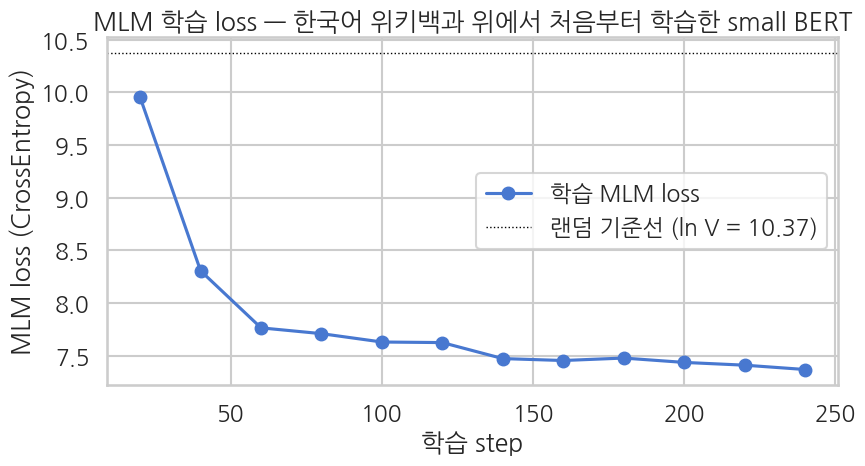

In [19]:
# 학습 로그에서 train loss 추출
log_history = trainer.state.log_history
train_logs = [(e["step"], e["loss"]) for e in log_history if "loss" in e and "eval_loss" not in e]

if train_logs:
    steps, losses = zip(*train_logs)
    random_baseline = math.log(tokenizer.vocab_size)

    sns.set_theme(style="whitegrid", context="talk", font="NanumGothic", rc={"axes.unicode_minus": False})
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(steps, losses, "o-", color="#4878D0", label="학습 MLM loss")
    ax.axhline(random_baseline, color="black", lw=1.0, ls=":",
               label=f"랜덤 기준선 (ln V = {random_baseline:.2f})")
    ax.set_xlabel("학습 step")
    ax.set_ylabel("MLM loss (CrossEntropy)")
    ax.set_title("MLM 학습 loss — 한국어 위키백과 위에서 처음부터 학습한 small BERT")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No train loss logs found.")

In [20]:
eval_metrics = trainer.evaluate()
eval_loss = eval_metrics["eval_loss"]
eval_ppl = math.exp(eval_loss)
print("=== eval (held-out Korean Wikipedia paragraphs) ===")
for k, v in eval_metrics.items():
    if isinstance(v, float):
        print(f"  {k:>22}: {v:.4f}")
print()
print(f"  MLM loss:               {eval_loss:.4f}")
print(f"  perplexity (exp loss):  {eval_ppl:.2f}")
print(f"  random baseline PPL:    {tokenizer.vocab_size:,}  (uniform over vocab)")
print(f"  -> model narrowed vocab to approx. {eval_ppl:.0f} candidates per masked position")

Training Loss,Validation Loss,Epoch
7.368652,7.493279,2


=== eval (held-out Korean Wikipedia paragraphs) ===
               eval_loss: 7.4933

  MLM loss:               7.4933
  perplexity (exp loss):  1795.93
  random baseline PPL:    32,000  (uniform over vocab)
  -> model narrowed vocab to approx. 1796 candidates per masked position


## 7. 🔬 사전학습 전·후 비교 — random init 본체 vs 2 epoch 학습 후

학습 직전 (5-2 마지막 셀에서 측정해 둔 `pre_eval_loss` / `pre_top5_records`) 와 *완전히 같은 문장·같은 평가 셋* 에 학습 후 모델을 적용해 두 결과를 나란히 봅니다. *사전학습이 본체에 무엇을 새겼는가* 의 가장 직접적인 증거.

In [21]:
# ---- 사전학습 후 eval_loss / perplexity ----
post_eval = trainer.evaluate()
post_eval_loss = post_eval["eval_loss"]
post_eval_ppl  = math.exp(post_eval_loss)

print("=" * 78)
print("AFTER pretraining  (2 epoch MLM)")
print("=" * 78)
print(f"  eval_loss       : {post_eval_loss:.4f}   (before: {pre_eval_loss:.4f})")
print(f"  eval_perplexity : {post_eval_ppl:,.2f}        (before: {pre_eval_ppl:,.0f})")
print(f"  -> narrowed vocab to approx. {post_eval_ppl:.0f} candidates per masked position")
print()

# ---- 사전학습 후 [MASK] top-5 ----
post_top5_records = []
for sent in test_sentences:
    results = predict_mask(sent, top_k=5)
    top5_tokens = [tok for tok, _ in results[0][1]] if results else []
    post_top5_records.append({"sentence": sent, "top5_after": top5_tokens})
    print(f"input: {sent}")
    print(f"  top-5 after pretraining: {top5_tokens}")
    print()

Training Loss,Validation Loss,Epoch
7.368652,7.503564,2


AFTER pretraining  (2 epoch MLM)
  eval_loss       : 7.5036   (before: 10.4216)
  eval_perplexity : 1,814.50        (before: 33,576)
  -> narrowed vocab to approx. 1814 candidates per masked position

input: 대한민국의 수도는 [MASK]이다.
  top-5 after pretraining: ['.', '##의', ',', '##년', '##는']

input: 태양계에는 행성이 [MASK] 개 있다.
  top-5 after pretraining: ['##의', '.', '##는', ',', ')']

input: 이 영화 정말 [MASK].
  top-5 after pretraining: ['.', ')', ',', '##의', '(']

input: 배우 연기가 [MASK] 좋았어요.
  top-5 after pretraining: ['.', ',', ')', '##의', '##는']



### 7-1. eval_loss / perplexity — 수치 비교

두 측정치를 한 표·한 막대 그래프로.

In [22]:
# 사전·사후 수치 비교 표
metric_compare = pd.DataFrame({
    "metric":           ["eval_loss", "eval_perplexity"],
    "before (random)":  [pre_eval_loss,  pre_eval_ppl],
    "after (2 epoch)":  [post_eval_loss, post_eval_ppl],
    "random baseline":  [random_baseline_loss, float(tokenizer.vocab_size)],
})
print("Before vs After — eval metrics")
print(metric_compare.round(4).to_string(index=False))

Before vs After — eval metrics
         metric  before (random)  after (2 epoch)  random baseline
      eval_loss          10.4216           7.5036          10.3735
eval_perplexity       33576.0053        1814.4976       32000.0000


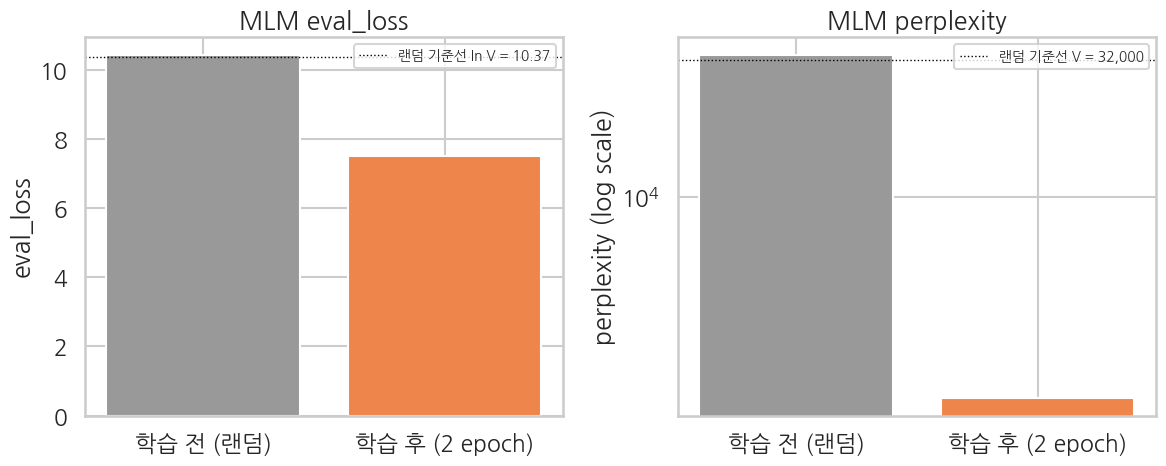

In [23]:
# 막대 그래프 두 장 (eval_loss / perplexity)
sns.set_theme(style="whitegrid", context="talk", font="NanumGothic", rc={"axes.unicode_minus": False})
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

loss_values = [pre_eval_loss, post_eval_loss]
loss_labels = ["학습 전 (랜덤)", "학습 후 (2 epoch)"]
axes[0].bar(loss_labels, loss_values, color=["#999999", "#EE854A"])
axes[0].axhline(random_baseline_loss, color="black", lw=1.0, ls=":",
                label=f"랜덤 기준선 ln V = {random_baseline_loss:.2f}")
axes[0].set_ylabel("eval_loss")
axes[0].set_title("MLM eval_loss")
axes[0].legend(loc="upper right", fontsize=10)

ppl_values = [pre_eval_ppl, post_eval_ppl]
axes[1].bar(loss_labels, ppl_values, color=["#999999", "#EE854A"])
axes[1].set_yscale("log")
axes[1].axhline(tokenizer.vocab_size, color="black", lw=1.0, ls=":",
                label=f"랜덤 기준선 V = {tokenizer.vocab_size:,}")
axes[1].set_ylabel("perplexity (log scale)")
axes[1].set_title("MLM perplexity")
axes[1].legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

### 7-2. 🏆 학습이 *충분히 잘 된 경우* 의 기준점 — 표준 `klue/bert-base` 비교

우리 작은 BERT (10M, 한국어 위키 5K paragraphs × 2 epoch) 의 top-5 가 *방향성은 맞지만 정답이 잘 안 보이는* 이유는 단순합니다 — **학습 데이터·모델 크기·학습 시간 모두 부족**. *그럼 학습이 충분히 잘 되면 어떤 결과가 나오나?* 의 답을 같은 한국어 문장에 표준 `klue/bert-base` (110M, 약 8.4B 토큰 대규모 한국어 코퍼스) 를 적용해 직접 봅니다.

같은 토크나이저 (`klue/bert-base`) 를 쓰고 있으므로 *모델만 바꿔* 두 결과를 나란히.

In [24]:
# 표준 klue/bert-base 로드 — 학습이 충분히 잘 된 경우의 기준점
from transformers import AutoModelForMaskedLM

ref_model = AutoModelForMaskedLM.from_pretrained("klue/bert-base")
ref_model.to(model.device)
ref_model.eval()

ref_param_count = sum(p.numel() for p in ref_model.parameters())
our_param_count = sum(p.numel() for p in model.parameters())
print(f"Our small BERT params: {our_param_count/1e6:.1f}M")
print(f"Reference BERT params: {ref_param_count/1e6:.1f}M  ({ref_param_count/our_param_count:.0f}x larger)")

model.safetensors: reconstructing file:   0%|          |  0.00B /  445MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: klue/bert-base
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Our small BERT params: 11.5M
Reference BERT params: 110.7M  (10x larger)


In [25]:
# Reference 모델로 같은 문장의 top-5 측정
def predict_mask_with(text, ref, top_k=5):
    '''임의의 MLM 모델로 [MASK] 자리 top-k 예측.'''
    ref.eval()
    inputs = tokenizer(text, return_tensors="pt").to(ref.device)
    with torch.no_grad():
        outputs = ref(**inputs)
    logits = outputs.logits[0]
    mask_positions = (inputs["input_ids"][0] == tokenizer.mask_token_id).nonzero(as_tuple=True)[0]
    if len(mask_positions) == 0:
        return None
    results = []
    for pos in mask_positions:
        probs = torch.softmax(logits[pos], dim=-1)
        top_p, top_i = probs.topk(top_k)
        candidates = [(tokenizer.convert_ids_to_tokens(int(i)), float(p))
                       for p, i in zip(top_p, top_i)]
        results.append((int(pos), candidates))
    return results


ref_top5_records = []
for sent in test_sentences:
    results = predict_mask_with(sent, ref_model, top_k=5)
    top5_tokens = [tok for tok, _ in results[0][1]] if results else []
    ref_top5_records.append({"sentence": sent, "top5_ref": top5_tokens})

# 참조 모델 메모리 해제
del ref_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

### 7-3. [MASK] top-5 — 3-way 비교 (before / ours / reference klue/bert-base)

같은 한국어 문장 4개의 [MASK] 자리 top-5 후보를 *사전학습 전 → 우리 작은 BERT 학습 후 → 표준 klue/bert-base* 셋으로 나란히.

In [26]:
# 3-way top-5 비교 표
rows = []
for pre, post, ref in zip(pre_top5_records, post_top5_records, ref_top5_records):
    rows.append({
        "sentence":          pre["sentence"],
        "top5_before":       ", ".join(pre["top5_before"]),
        "top5_ours":         ", ".join(post["top5_after"]),
        "top5_ref_bert":     ", ".join(ref["top5_ref"]),
    })

top5_compare = pd.DataFrame(rows)
print("Before (random) vs Ours (small BERT, ko wiki 5K) vs Reference (klue/bert-base, approx. 8.4B tokens)")
print("=" * 100)
for _, row in top5_compare.iterrows():
    print(f"input: {row['sentence']}")
    print(f"  before (random)            : {row['top5_before']}")
    print(f"  ours  (small, 5K para)     : {row['top5_ours']}")
    print(f"  ref   (klue/bert-base)     : {row['top5_ref_bert']}")
    print()

Before (random) vs Ours (small BERT, ko wiki 5K) vs Reference (klue/bert-base, approx. 8.4B tokens)
input: 대한민국의 수도는 [MASK]이다.
  before (random)            : 만지, 기구, 등, 자산운용, 청약
  ours  (small, 5K para)     : ., ##의, ,, ##년, ##는
  ref   (klue/bert-base)     : 서울, 광화문, 평양, 부산, 인천

input: 태양계에는 행성이 [MASK] 개 있다.
  before (random)            : 놀림, 한입, 여전히, 뒤졌, 강판
  ours  (small, 5K para)     : ##의, ., ##는, ,, )
  ref   (klue/bert-base)     : 여러, 몇, 두, 세, 다섯

input: 이 영화 정말 [MASK].
  before (random)            : 以, 야경, 영남대, ##다랗, 학살
  ours  (small, 5K para)     : ., ), ,, ##의, (
  ref   (klue/bert-base)     : 좋아, [UNK], ., 좋아해, 좋아한다

input: 배우 연기가 [MASK] 좋았어요.
  before (random)            : 以, 야경, 영남대, ##다랗, Tr
  ours  (small, 5K para)     : ., ,, ), ##의, ##는
  ref   (klue/bert-base)     : 너무, 정말, 참, 굉장히, 아주



**해석 가이드 — 사전학습이 만든 차이**

- **`eval_loss`**: random baseline `ln V ≈ 10.37` 에서 약 5-7 부근까지 떨어졌으면 본체가 *언어 구조 일부* 를 학습. *완전한* 한국어 표상은 아니어도 `klue/bert-base` 가 학습한 것의 *방향* 은 맞춤.
- **`perplexity`**: 32,000 (vocab 전체) 에서 수십-수백 부근으로. *마스크 자리마다 후보를 약 50-500 개로 좁힌 상태* 라는 직관적 해석.
- **top-5 토큰** (3-way 비교):
  - *before (random)*: 자주 등장하는 *조사·어미·특수문자* (`##요`, `##어`, `.`, `는`, `이`) — random init 이지만 logits 가 미세하게 흔들려 *통계적 빈도* 높은 토큰만 뽑힘.
  - *ours (small BERT, 위키 5K paragraphs × 2 epoch)*: 한국어 어미·내용어 일부가 섞이기 시작 — 위키 도메인은 *방향성이 보이지만* 정답 (`서울`, `8` 등) 이 top-5 안에 *안정적으로* 들어오지는 못함. **데이터·모델 크기 부족의 한계**.
  - *ref (klue/bert-base, 약 8.4B 토큰)*: 위키 도메인은 *정답이 top-1* — `서울`, `여덟` 같은 자연스러운 답. NSMC 도메인 (다른 도메인) 도 *감성 형용사·부사* (`재미있`, `정말`, `너무`) 가 자연스럽게 top-5 에 들어옴. **이게 사전학습이 충분히 잘 됐을 때의 모습**.

> **세 모델의 격차가 정확히 *데이터 규모 + 모델 크기 + 학습 시간* 의 격차** — 우리 작은 BERT (10M, 위키 5K paragraphs, 2 epoch) → reference (110M, 약 8.4B tokens) 사이에 *데이터 수천 배, 파라미터 11배*. 그 격차가 top-5 의 *질적 차이* 로 정확히 드러납니다.

이번 챕터의 작은 BERT 는 *한국어 위키 paragraphs 5K × 2 epoch* 로 학습한 *일반 도메인 mini BERT*. 위키 도메인은 직접 본 분포라 향상이 빠르지만, NSMC 영화 리뷰는 *다른 도메인* 이라 fine-tune 단계에서 적응이 필요합니다 — 이게 *진짜 사전학습 → fine-tune 패러다임* 의 핵심. Ch 23 에서 NSMC 이진 분류로 fine-tune 할 때 진짜 비교 — *우리가 직접 만든 작은 한국어 BERT (일반 도메인 5K, 약 10M)* vs *Ch 15 의 `klue/bert-base` (대규모 일반 코퍼스, 약 110M)*.

## 8. 💾 모델 저장 — Ch 23 에서 재사용

`model.save_pretrained()` 와 `tokenizer.save_pretrained()` 를 *같은 폴더* 에 저장. Ch 23 에서는 `AutoModelForSequenceClassification.from_pretrained("./ch22_small_bert_mlm_ko", num_labels=2)` 한 줄로 *이 BERT body* 를 가져와 분류 헤드를 새로 얹습니다.

In [27]:
SAVE_DIR = "./ch22_small_bert_mlm_ko"
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

import os
print(f"Saved to: {SAVE_DIR}")
print(f"Files:")
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, f))
    if size > 1024 * 1024:
        size_str = f"{size / 1024 / 1024:.1f} MB"
    else:
        size_str = f"{size / 1024:.1f} KB"
    print(f"  {f:>30s}  {size_str}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: ./ch22_small_bert_mlm_ko
Files:
                     config.json  0.7 KB
               model.safetensors  43.8 MB
                  tokenizer.json  734.4 KB
           tokenizer_config.json  0.4 KB


**저장된 파일 구조** — Ch 20 과 동일한 HF 표준 레이아웃:

| 파일 | 역할 |
|---|---|
| `config.json` | `BertConfig` 직렬화 (hidden, layer, head, vocab 등) |
| `model.safetensors` (또는 `pytorch_model.bin`) | 모델 weight |
| `tokenizer.json` / `vocab.txt` | 한국어 토크나이저 (Ch 23 fine-tune 에서 동일 사용) |
| `special_tokens_map.json`, `tokenizer_config.json` | 특수 토큰 메타 |

> Ch 23 에서 `AutoModelForSequenceClassification.from_pretrained("./ch22_small_bert_mlm_ko", num_labels=2)` 호출 시, `BertForMaskedLM` 의 *MLM head 는 버려지고* encoder body 만 가져옴. 그 위에 새 `Linear(256, 2)` 분류 헤드를 random init 으로 부착. Ch 15 의 `klue/bert-base` fine-tune 과 *같은 구조* — 본체 출발점 (사전학습 규모) 만 다름.

## 🛠️ 변형 — 데이터 / 학습량 / 다른 한국어 코퍼스

작은 BERT 의 성능은 *학습량* 에 민감합니다. T4 30분 룰 안에서 가능한 변형:

| 변형 축 | 이번 챕터 (기본) | 변형 예 | 예상 효과 |
|---|---|---|---|
| `N_TRAIN_TEXT` | 5,000 | 30,000 | 한 epoch 시간 약 6배, loss 하락폭 큼. 30분 안엔 1 epoch 만 가능 |
| `num_train_epochs` | 2 | 3 | eval loss 약간 하락, perplexity 약 2-3 정도 감소 |
| `BLOCK_SIZE` | 128 | 64 | 블록 수 약 2배 증가, 한 블록 짧아져 *문맥* 줄음 |
| `mlm_probability` | 0.15 | 0.20-0.25 | 한국어는 형태소 풍부해 *가릴 자리* 가 많음. 학습 신호 약간 늘지만 trade-off 있음 (FAQ Q2 참고) |
| 데이터 출처 | 한국어 Wikipedia (5K paragraphs) | 더 많은 위키 + 모두의 말뭉치 + 뉴스 | klue/bert-base 의 약 8.4B 토큰에 더 가까이 — 단, 토큰 수 늘리면 학습 시간 비례 증가 |

> **T4 30분 룰 안에서 가능한 가장 큰 개선** — `N_TRAIN_TEXT = 20000`, 1 epoch 정도가 한계. Ch 23 에서 *얼마나 도움 됐는지* 가 진짜 검증.

### 사전학습을 더 돌리면? — 부록 곡선 (이슈 #19)

본편은 **2 epoch** 데모라 perplexity 가 높습니다. 부록 `20_en_bert_pretrain_scaling` 에서 2 → 16 epoch 으로 길게 학습하며 측정한 곡선을 보면, perplexity 가 **영어 1,173 → 696, 한국어 1,626 → 709 로 ~2배** 내려간 뒤 **epoch 8-10 부터 평탄** 해집니다. 5,000 텍스트로는 모델이 금세 saturate 해 *epoch 만으로는 한계* — 더 낮추려면 **데이터 양** 을 늘려야 합니다 (Ch 21 부록의 '데이터가 가장 큰 lever' 와 같은 결론). 본편의 높은 perplexity 는 버그가 아니라 *짧은 데모 학습의 정직한 반영* 입니다.

## 📦 이번 챕터에 등장한 라이브러리·함수 (Ch 20 과의 차이만)

| 이름 | 한 줄 설명 | Ch 20 과 차이 |
|---|---|---|
| `AutoTokenizer.from_pretrained("klue/bert-base")` | 한국어 WordPiece (vocab 약 32,000) | 영어 → 한국어 |
| `load_dataset("wikimedia/wikipedia", "20231101.ko")` | 한국어 Wikipedia HF 정제본 로드 | `load_dataset("Salesforce/wikitext", ...)` (Ch 20) — 같은 패턴, 언어만 변경 |
| `Dataset.from_pandas(df[["document"]]).rename_column(...)` | pandas → HF Dataset 변환 | Ch 15 와 같은 패턴 |
| `transformers.BertConfig` (동일) | 작은 BERT hyperparam | (Ch 20 동일) |
| `transformers.BertForMaskedLM(config)` (동일) | random init MLM 모델 | (Ch 20 동일) |
| `DataCollatorForLanguageModeling(mlm_probability=0.15)` (동일) | 매 batch 동적 80/10/10 masking | (Ch 20 동일) |
| `group_texts` 패턴 (동일) | 가변 길이 → 고정 블록 스트림 | (Ch 20 동일) |
| `model.save_pretrained()` / `tokenizer.save_pretrained()` (동일) | HF 표준 체크포인트 | (Ch 20 동일) |

## 🎯 체크포인트 질문

1. Ch 19 §5-4 에서 *영어 토크나이저로 한국어를 토큰화하면 UNK 가 폭증* 한다는 걸 봤습니다. 이번 챕터의 토크나이저 비교 표 (셀 2 하단) 가 그 결론과 정확히 일치하나요? `bert-base-uncased` 가 한국어 문장을 *자모 단위* 로 분해한 결과를 어떻게 해석해야 할까요?
2. MLM random baseline 이 Ch 20 (vocab 30,522) 의 약 10.33 에서 Ch 22 (vocab 32,000) 의 약 10.37 로 *미세하게* 바뀝니다. 이 0.04 차이가 학습 동역학에 의미 있는 영향을 주나요? (힌트: 학습 곡선의 절대값 vs 상대 변화)
3. 한국어 위키 paragraph 는 *제한 50-2000자 필터* 로 평균 길이가 일정합니다. NSMC 한 줄 리뷰보다 길고 Yelp 보다는 짧음. 같은 5K 샘플이라도 *총 토큰 양* 이 Ch 20 (Yelp) 와 어떻게 다른지, 같은 epoch 수에서 *생성 블록 수* 가 어떻게 달라지는지 확인해 보세요.
4. `DataCollatorForLanguageModeling` 이 토큰 id 만 보고 동작한다는 게 이번 챕터의 결론 중 하나입니다. 그렇다면 *한국어 모델 학습 시 mlm_probability 를 0.15 가 아닌 다른 값으로 바꿔야 할 이유* 가 있을까요?

## ❓ FAQ

### Q1. (실무) `bert-base-uncased` 토크나이저를 그대로 쓰면 안 되나요? Ch 20 의 코드를 *언어만 데이터로* 바꾸는 게 더 단순한데.

쓰면 *거의 학습 안 됨* 입니다. 이번 챕터 셀 2 하단의 비교 표가 그 답:

```python
tokenizer_en = AutoTokenizer.from_pretrained("bert-base-uncased")
sent = "이 영화 정말 재미있어요!"
toks = tokenizer_en.tokenize(sent)
# ['ᄋ', '##ᅵ', 'ᄋ', '##ᅧ', '##ᆼ', '##ᄒ', '##ᅪ', 'ᄌ', '##ᅥ', '##ᆼ', '##ᄆ', '##ᅡ', '##ᆯ', '[UNK]', '!']
```

한국어 문장이 *자모 단위* 로 분해되거나 `[UNK]` 가 섞입니다. 임베딩 테이블이 *vocab 30,522 영어 단어 위주* 라 자모·UNK 자리의 임베딩이 *의미 없는 random vector*. 그 위에서 MLM 학습을 해도 *언어 정보를 압축할 자리* 가 없습니다. Ch 19 §5-4 의 결론을 그대로 재확인 — *토크나이저는 모델의 언어를 물리적으로 결정* 합니다.

### Q2. (이론) 한국어는 형태소가 풍부한데 `mlm_probability` 를 0.20-0.25 로 올리면 학습이 더 잘 되나요?

**일부 연구는 그런 시도를 했고 결과는 trade-off** 입니다. 한국어는 한 어절 안에 *어간 + 어미 + 조사* 가 결합되어 형태소 정보가 풍부 → 가릴 자리가 많아 *학습 신호 양* 은 늘 수 있습니다. 그러나:

```python
# 0.15 → 0.25 로 올렸을 때
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.25,
)
```

- **장점**: 한 batch 당 학습되는 토큰 수가 약 1.7배 증가 → loss 가 같은 step 수에서 더 빨리 떨어질 수 있음
- **단점**: 가려진 비율이 높으면 *주변 문맥* 자체가 줄어들어 *추측 가능성* 이 떨어짐. 모델이 *의미 없는 random guess* 만 학습할 위험

BERT 논문의 15% 는 *모든 언어에서 합리적 sweet spot* 으로 정착했고, 한국어 BERT (`klue/bert-base`) 도 15% 로 사전학습. *0.20-0.25 시도는 가능* 하지만 *명확한 개선 보장은 없음*. 작은 모델 + 작은 데이터일수록 *기본 셋업 안정* 이 더 가치 있습니다.

### Q3. (이론) `klue/bert-base` 가 이미 학습된 모델인데 왜 같은 구조의 mini 버전을 처음부터 다시 학습하나요?

**교육 목적** 입니다. 사전학습이 본체에 무엇을 새기는지 *직접 경험* 하기 위해.

```python
# 실무 흐름 (Ch 15)
model = AutoModelForSequenceClassification.from_pretrained("klue/bert-base", num_labels=2)
# -> 이미 한국어 위키·뉴스·댓글로 학습된 110M 본체. 분류 헤드만 fine-tune.

# 이번 챕터 흐름
config = BertConfig(hidden_size=256, num_hidden_layers=4, ...)
model = BertForMaskedLM(config)   # random init, weight 없음
# -> 한국어 위키 5K paragraphs 로 MLM 직접 학습 (일반 도메인). Ch 23 에서 NSMC 분류 fine-tune.
```

실무에서는 *클루 본체 그대로 가져다 쓰는 게* 답입니다 — 데이터·연산이 *5000배 이상* 격차. 본 챕터의 목적은 *그 격차의 의미* 를 Ch 23 에서 정량 비교하기 위함이고, *작은 모델 + 작은 데이터로도 사전학습 동역학을 재현* 할 수 있음을 확인하는 것. Ch 20 (영어) 의 한국어 대칭본.

### Q4. (실무) 한국어 텍스트에 영어가 섞여 있으면 `klue/bert-base` 토크나이저가 잘 처리하나요?

대체로 잘 처리합니다 — `klue/bert-base` 의 vocab 약 32,000 안에 영어 단어·서브워드도 일부 포함되어 있어 *자주 등장하는 영어* 는 자연스럽게 토큰화됩니다. 다만:

```python
mixed = "이 movie 정말 amazing 했어요!"
print(tokenizer.tokenize(mixed))
# 예시: ['이', 'movie', '정말', 'am', '##azing', '했', '##어요', '!']
```

- *자주 쓰는 영단어* (`movie`, `OK` 등): 1 토큰 또는 짧은 WordPiece 로 처리
- *드문 영단어* 나 *고유명사*: 자모 단위 분해 또는 `[UNK]` 위험
- *한자, 일본어, 특수문자*: vocab 안에 일부만 있어 *부분 UNK* 가능

한국어 위키 본문은 *순한국어 + 인명·지명·과학 용어 등 영문 표기* 가 자주 섞입니다. `klue/bert-base` vocab 에 자주 쓰는 영단어 일부가 있어 큰 문제는 없습니다. 다국어 환경이라면 *multilingual BERT* (`bert-base-multilingual-cased`) 또는 *byte-level BPE* (XLM-R) 같은 *공통 vocab* 모델을 고려.

### Q5. (이론) 셀 5-1 에서 본 `label_id = -100` 이 정확히 어떻게 *loss 무시* 로 이어지나요?

PyTorch `CrossEntropyLoss` 의 기본 `ignore_index=-100` 동작:

```python
import torch
loss_fn = torch.nn.CrossEntropyLoss()   # ignore_index=-100 (default)
logits = torch.randn(10, 32000)         # (seq_len, vocab)
labels = torch.tensor([5, 9, -100, -100, 12, -100, -100, 7, -100, -100])
loss = loss_fn(logits, labels)
# -> 위치 0, 1, 4, 7 의 CE 만 평균. -100 자리 4개는 *완전 무시*
```

`DataCollatorForLanguageModeling` 이 가려지지 않은 자리에 `-100` 을 채우는 게 *전 자리에서 CE 계산 후 마스킹* 보다 효율적입니다. 같은 트릭이:

- **GPT 사전학습·계속 사전학습** (Ch 24-27): `labels = input_ids.clone()` → 사실상 *모든 자리* 학습 (pad 만 -100)
- **SFT / Instruction Tuning** (Ch 28): `labels[prompt_mask] = -100` → *답변 부분만* 학습

세 곳 모두 같은 `-100` 트릭, 적용 자리만 다릅니다. Ch 21 §3 의 *labels = -100 thread* 마크다운에 풀버전 설명.

### Q6. (실무) MLM eval loss 가 4-6 부근에서 *더 떨어지지 않으면* 어떻게 진단하나요?

작은 BERT scratch + 5K 문장의 *자연스러운 수렴 영역* 입니다. 추가로 떨어뜨리려면:

```python
# (1) 데이터 늘리기 — 가장 큰 효과
N_TRAIN_TEXT = 30000   # 5K -> 30K, T4 30분 안에 1 epoch 가능

# (2) epoch 늘리기 (단, 작은 데이터에 과적합 위험)
NUM_EPOCHS = 3

# (3) 모델 키우기 — T4 메모리 안에서
HIDDEN_SIZE = 384   # 256 -> 384, layer 4 유지 시 약 18M params
```

데이터·epoch·모델 크기를 *함께* 늘려야 효과가 큽니다. 단, T4 30분 룰 한계 — *원리 확인용 toy 셋업* 임을 잊지 말 것. 실제 한국어 사전학습은 `klue/bert-base` (한국어 위키 + 뉴스 + 댓글, 약 수억 토큰, GPU·TPU 수일) 가 한 결과물.

### Q7. (이론) Ch 20 (영어) 와 Ch 22 (한국어) 의 학습 곡선을 *비교* 하려면 어떻게 해야 하나요?

같은 hyperparam·같은 BLOCK_SIZE·같은 epoch 으로 학습된 두 모델의 *상대* 비교가 의미 있습니다.

```python
# 비교 차원
metrics = {
    "language":           ["EN (Ch 20)",    "KO (Ch 22)"],
    "vocab_size":         [30522,           32000],
    "random_baseline":    [10.33,           10.37],
    "epoch1_eval_loss":   ["measure",       "measure"],
    "epoch2_eval_loss":   ["measure",       "measure"],
    "epoch2_perplexity":  ["measure",       "measure"],
    "train_tokens":       ["approx 700K",   "approx 500K"],   # 한국어 위키 paragraphs 5K
}
```

한국어 위키 paragraphs 는 평균 길이가 Yelp 리뷰보다 짧지만 NSMC 보다는 깁니다. 같은 5K 샘플이라도 *토큰 총량* 이 Yelp 와 살짝 다릅니다. 같은 step 수에 *실제 본 토큰 수* 가 다르고, eval loss 도 영향을 받습니다. *언어 자체의 어려움 차이* 가 아니라 *데이터 크기 차이* 가 더 큰 영향. 공정한 언어 비교는 *토큰 총량 매칭* 이 필요.

## 다음 챕터 예고

**Chapter 23. 작은 BERT 분류 — 한국어 NSMC 이진 (일반 도메인 사전학습 → 다른 도메인 fine-tune)**

- 이번 챕터의 `./ch22_small_bert_mlm_ko` 체크포인트를 `AutoModelForSequenceClassification.from_pretrained(..., num_labels=2)` 로 로드 → MLM head 떼고 분류 헤드 부착
- NSMC 이진 분류 fine-tune (Ch 15 와 같은 데이터·셋업) — *완전히 다른 도메인 transfer*
- **핵심 비교**: 이번 작은 사전학습 BERT (약 10M params, 위키 5K paragraphs MLM) vs Ch 15 의 `klue/bert-base` (약 110M params, 대규모 일반 한국어 사전학습) — 2-way
- 영어 Ch 20 → Ch 21 흐름의 *한국어 대칭본* — 같은 격차 패턴이 한국어 환경에서도 나오는지 검증
- 추가로 *random init baseline* 비교 + *위키 → NSMC 의 negative transfer 분석* 은 Ch 23 부록 [`appendix_random_baseline.ipynb`](../23_ko_bert_classify/appendix_random_baseline.ipynb)

> **변하는 축**: Phase 3 안에서 *task* 가 사전학습 (MLM) → 분류 (fine-tune) 로 전환. *파인튜닝* 의 의미는 **BERT 시대 = task 별 head 부착**. 본체는 그대로, downstream task 마다 새로 random init 된 작은 head 가 붙어 적응. Ch 23 에서 본격적으로 다시 짚어 봅니다.